# 911 Calls: Emergency Response Patterns in Montgomery County, PA

Analysis of roughly 99,500 emergency call records from Montgomery County, PA ([source: Kaggle](https://www.kaggle.com/mchirico/montcoalert)), covering call reasons, geographic distribution, and time-based patterns.

**Columns**
* `lat`, `lng` — call location
* `desc` — description of the emergency
* `zip`, `twp`, `addr` — location fields
* `title` — call classification code (e.g. `EMS: BACK PAINS/INJURY`)
* `timeStamp` — when the call was placed
* `e` — dummy column, always 1, not used

## Data and Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df = pd.read_csv('911.csv')

## First Look at the Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


In [6]:
df.head(6)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1
5,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS: HEAD INJURY,2015-12-10 17:40:01,LANSDALE,CANNON AVE & W 9TH ST,1


## Call Volume by Location

In [11]:
df['zip'].value_counts().head(5)

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

In [12]:
df['twp'].value_counts().head(5)

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

Conclusion: Lower Merion, Abington, Norristown, Upper Merion, and Cheltenham townships (zip codes in the 19401–19406 range) generate the highest 911 call volume.

How many distinct call codes are packed into the `title` column?

In [26]:
df['title'].nunique()

110

These 110 codes collapse into three broad reasons — EMS, Fire, and Traffic — encoded as a prefix in `title` (e.g. `EMS: BACK PAINS/INJURY`).

## Grouping Calls by Reason

In [7]:
df['Reason'] = df['title'].apply(lambda title: title.split(':')[0])
df['Reason']

0            EMS
1            EMS
2           Fire
3            EMS
4            EMS
          ...   
99487    Traffic
99488    Traffic
99489        EMS
99490        EMS
99491    Traffic
Name: Reason, Length: 99492, dtype: object

In [40]:
df['Reason'].value_counts()

Reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

Conclusion: EMS accounts for about 49% of all calls (48,877), followed by Traffic (35,695) and Fire (14,920).

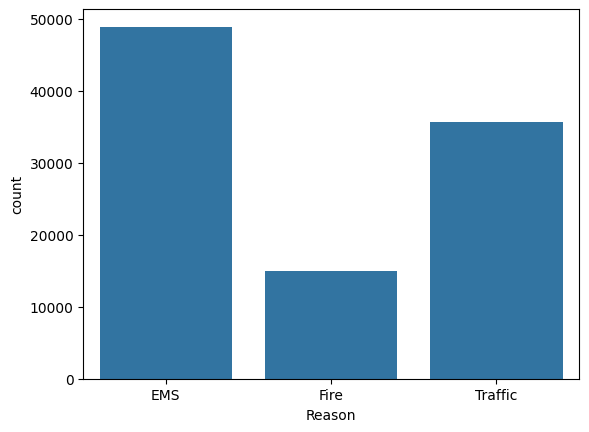

In [51]:
sns.countplot(x = 'Reason',data = df)
plt.show()

## Time-Based Patterns

In [84]:
type(df['timeStamp'].iloc[0])

pandas._libs.tslibs.timestamps.Timestamp

Convert `timeStamp` to proper datetime objects, then derive `Hour`, `Month`, and `Day of Week` columns for time-based analysis.

In [85]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

In [86]:
time = df['timeStamp'].iloc[3]
time.hour

17

In [87]:
df['Hour'] = df['timeStamp'].apply(lambda x: x.hour)
df['Month'] = df['timeStamp'].apply(lambda x: x.month)
df['Day of Week'] = df['timeStamp'].apply(lambda x: x.day_of_week)
df['Day of Week']

0        3
1        3
2        3
3        3
4        3
        ..
99487    2
99488    2
99489    2
99490    2
99491    2
Name: Day of Week, Length: 99492, dtype: int64

Map the numeric day-of-week values (0–6) to their names.

In [88]:
dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
dmap

{0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

In [89]:
df['Day of Week'] = df['Day of Week'].astype(int).map(dmap)
df['Day of Week']

0        Thu
1        Thu
2        Thu
3        Thu
4        Thu
        ... 
99487    Wed
99488    Wed
99489    Wed
99490    Wed
99491    Wed
Name: Day of Week, Length: 99492, dtype: object

### Calls by Day of Week and Reason

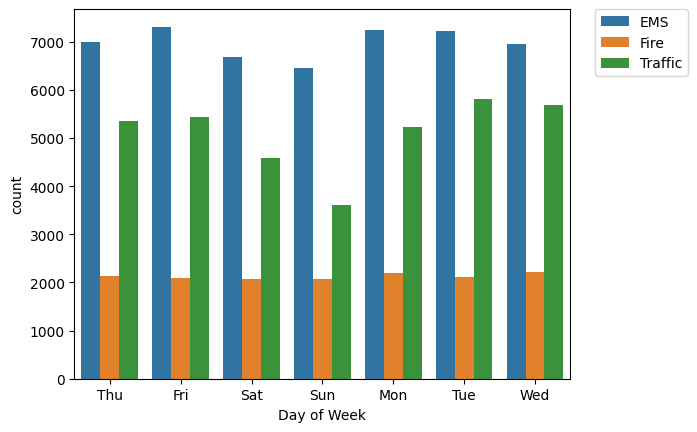

In [13]:
sns.countplot(x = 'Day of Week', hue = 'Reason', data = df)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

### Calls by Month and Reason

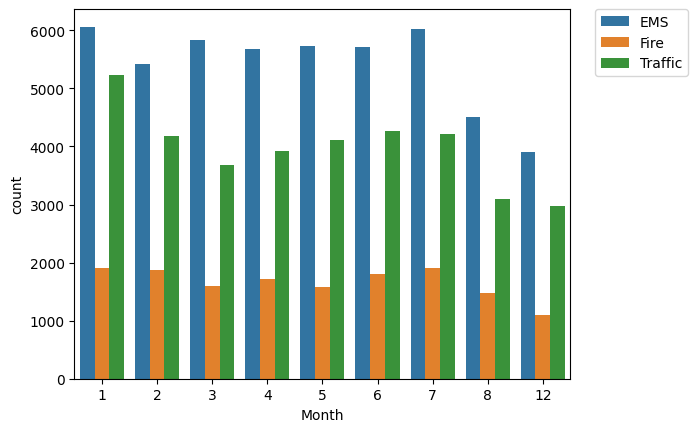

In [14]:
sns.countplot(data = df, x = 'Month', hue = 'Reason')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

The monthly count plot above skips any month with zero calls, which makes the trend hard to read. Grouping by month and plotting the counts directly fixes this.

In [31]:
byMonth = df.groupby('Month').count()
byMonth.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Day of Week
Month,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423


### Total Calls per Month

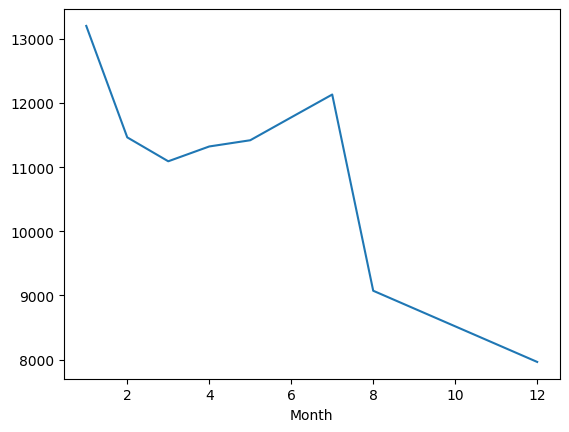

In [42]:
byMonth['twp'].plot()
plt.show()

A linear fit shows the overall trend across months more clearly than the raw counts:

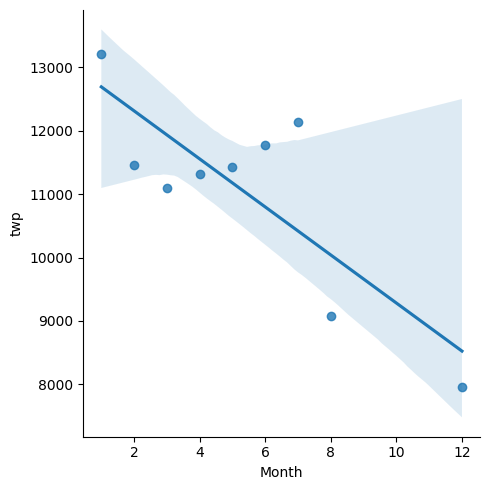

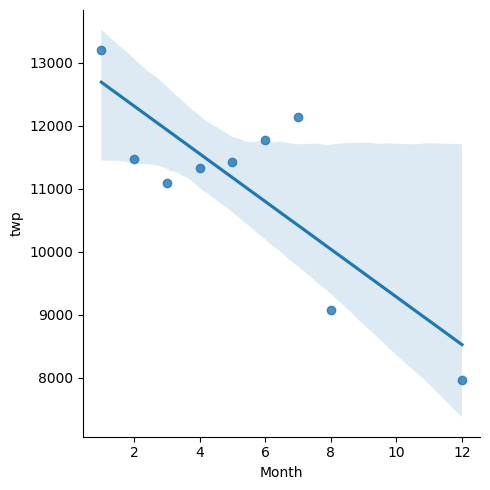

In [53]:
sns.lmplot(data = byMonth.reset_index(), x = 'Month', y = 'twp')
plt.show()

### Daily Call Volume

In [55]:
df['Date'] = df['timeStamp'].apply(lambda x: x.date())
df['Date']
#df['timeStamp']

0        2015-12-10
1        2015-12-10
2        2015-12-10
3        2015-12-10
4        2015-12-10
            ...    
99487    2016-08-24
99488    2016-08-24
99489    2016-08-24
99490    2016-08-24
99491    2016-08-24
Name: Date, Length: 99492, dtype: object

In [62]:
byDate = df.groupby('Date').count()['twp']
byDate.head()

Date
2015-12-10    115
2015-12-11    395
2015-12-12    403
2015-12-13    319
2015-12-14    446
Name: twp, dtype: int64

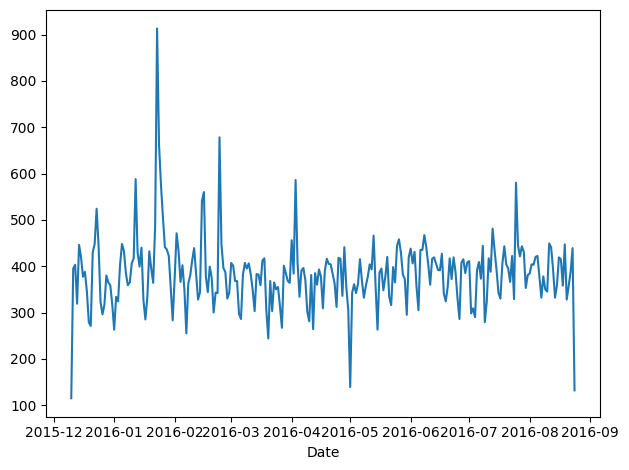

In [64]:
byDate.plot()
plt.tight_layout()
plt.show()

### Daily Call Volume by Reason

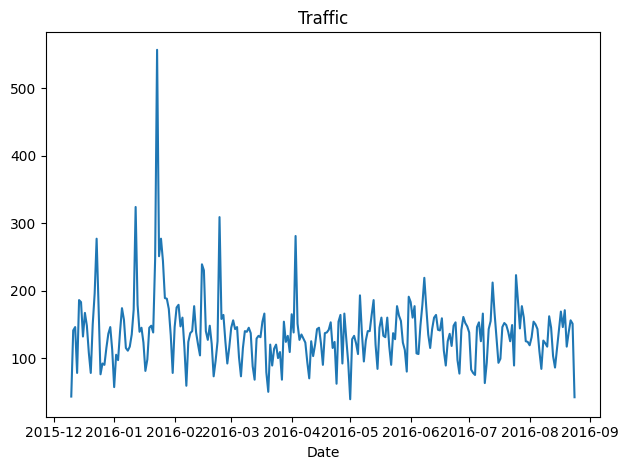

In [70]:
byDate = df[df['Reason']=='Traffic'].groupby('Date').count()['twp']
byDate.plot()
plt.title('Traffic')
plt.tight_layout()
plt.show()

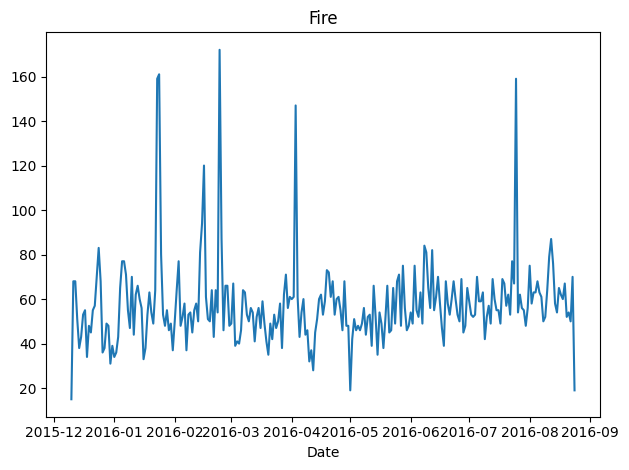

In [71]:
byDate = df[df['Reason']=='Fire'].groupby('Date').count()['twp']
byDate.plot()
plt.title('Fire')
plt.tight_layout()
plt.show()

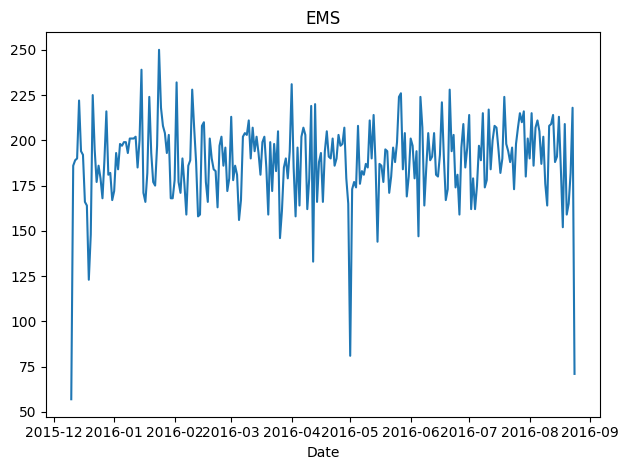

In [72]:
byDate = df[df['Reason']=='EMS'].groupby('Date').count()['twp']
byDate.plot()
plt.title('EMS')
plt.tight_layout()
plt.show()

## Heatmaps: Day of Week vs. Hour
Restructuring the data so days of week become rows and hours become columns makes it possible to visualize call density as a heatmap.

In [117]:
gpd_Day_of_Week = df.groupby(by = ['Day of Week','Hour']).count()['Reason'].unstack()
gpd_Day_of_Week

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354
Tue,269,240,186,170,209,239,415,655,889,880,...,943,938,1026,1019,905,731,647,571,462,274
Wed,250,216,189,209,156,255,410,701,875,808,...,904,867,990,1037,894,686,668,575,490,335


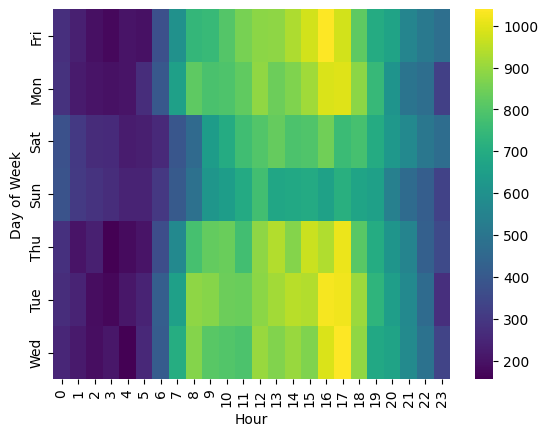

In [122]:
sns.heatmap(data = gpd_Day_of_Week,cmap = 'viridis')
plt.show()

A clustermap additionally reorders and groups similar days/hours together:

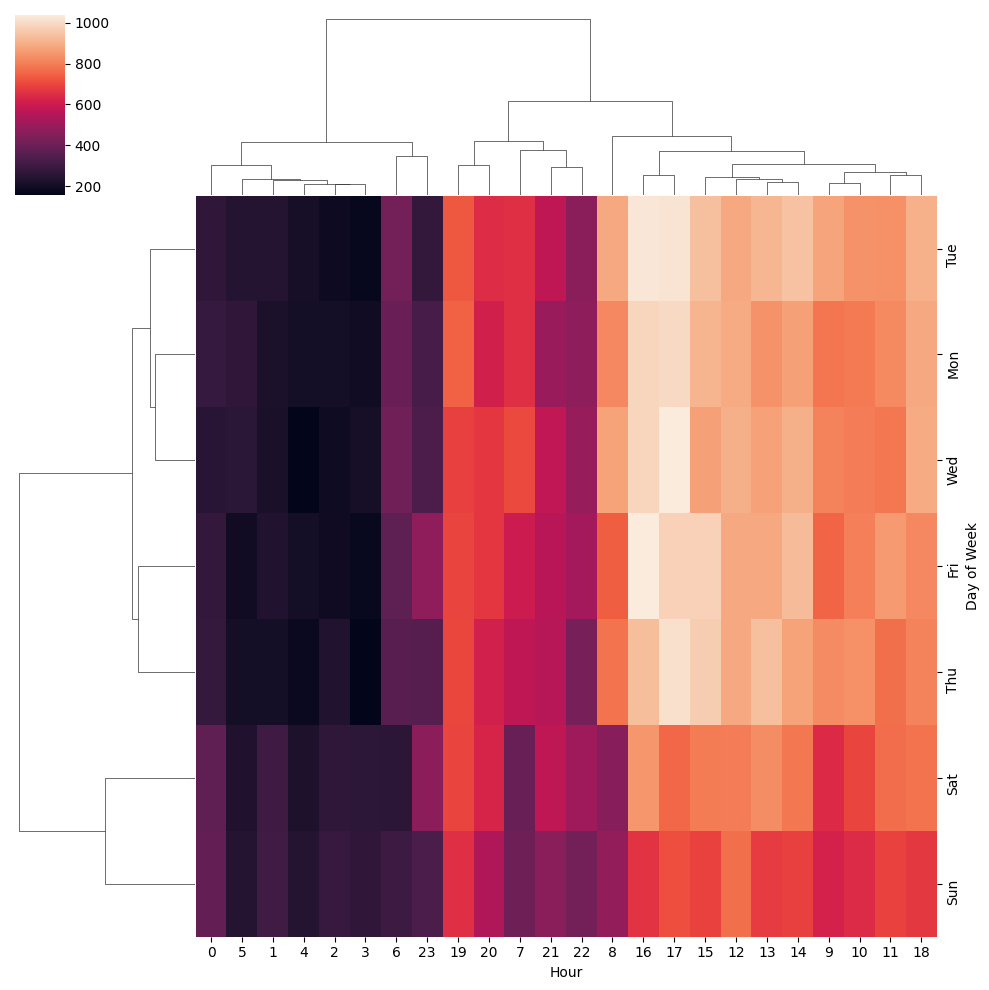

In [123]:
sns.clustermap(data = gpd_Day_of_Week)
plt.show()

## Heatmaps: Day of Week vs. Month

In [125]:
gpd_Day_of_Month = df.groupby(by = ['Day of Week','Month']).count()['Reason'].unstack()
gpd_Day_of_Month

Month,1,2,3,4,5,6,7,8,12
Day of Week,,,,,,,,,
Fri,1970,1581,1525,1958,1730,1649,2045,1310,1065
Mon,1727,1964,1535,1598,1779,1617,1692,1511,1257
Sat,2291,1441,1266,1734,1444,1388,1695,1099,978
Sun,1960,1229,1102,1488,1424,1333,1672,1021,907
Thu,1584,1596,1900,1601,1590,2065,1646,1230,1266
Tue,1973,1753,1884,1430,1918,1676,1670,1612,1234
Wed,1700,1903,1889,1517,1538,2058,1717,1295,1262


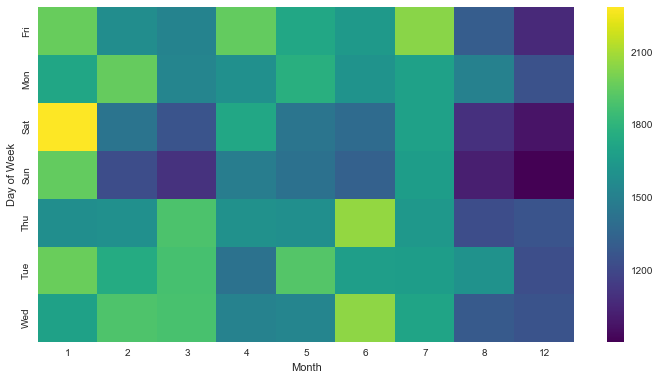

In [208]:
sns.heatmap(data = gpd_Day_of_Month)
plt.show()

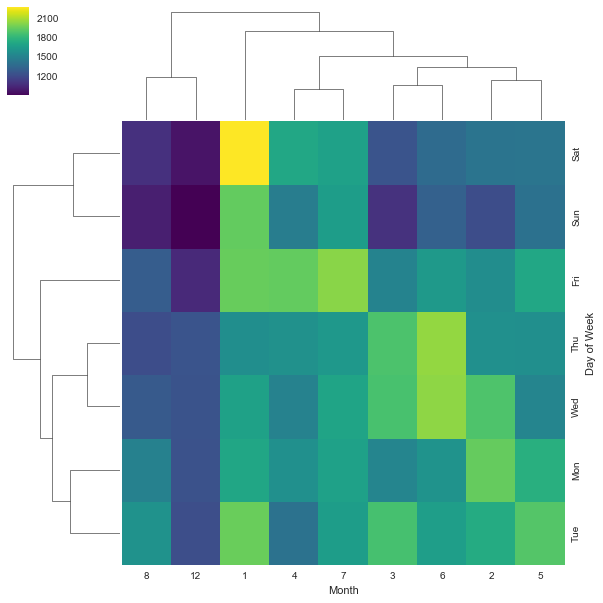

In [209]:
sns.clustermap(data = gpd_Day_of_Month)
plt.show()

## Key Takeaways
- EMS accounts for the largest share of calls (49%, 48,877 of 99,492) — nearly matching Traffic and Fire combined.
- Lower Merion, Abington, Norristown, Upper Merion, and Cheltenham townships (zip codes 19401–19406) generate the highest call volumes.
- Call volume varies by day of week, hour of day, and month, visible in the heatmaps and clustermaps above, which group similar time periods together.